# CM22009 Semester 2 Coursework (15%): Starter Notebook (Summative)

## Task
Predict hourly bike rental demand (`cnt`) from weather + calendar features using a deep neural network (MLP) trained with backpropagation.

This notebook is your submission. You must fill in all **TODO** sections.

---

## Environment + allowed packages
**Minimum Python:** 3.11 (recommended 3.11 or 3.12)

**Allowed packages:** only those in `requirements.txt`:
- numpy, pandas, matplotlib, scikit-learn, torch, ipykernel (tqdm optional)

**Not allowed:** AutoML or high-level frameworks that remove the need to implement training logic
(e.g., pytorch-lightning, fastai, autogluon, xgboost, catboost, prophet, sktime, gluonts, etc.).

---

## Data download + placement 
You must place the dataset file at:
- `./data/hour.csv`

Folder structure must be:
- `data/hour.csv`

If the notebook cannot find `data/hour.csv`, the submission is incomplete.

---

## How to run (VS Code / local)
1. Install Python 3.11+.
2. Create and activate a venv and install requirements:
   ```bash
   python -m venv .venv
   source .venv/bin/activate   # Windows: .venv\Scripts\activate
   pip install -U pip
   pip install -r requirements.txt
   ```
3. In VS Code: install Python + Jupyter extensions, then select the `.venv` kernel.
   If you see "requires ipykernel", run `pip install ipykernel` and restart.

## How to run (Google Colab)
1. Upload this notebook to Colab.
2. Upload `hour.csv` and ensure it is available at `/content/data/hour.csv`.
3. Install requirements:
   ```python
   !pip install -r requirements.txt
   ```

### Quick download (UCI) — optional convenience
You may download the dataset zip from UCI and extract `hour.csv`.

macOS/Linux:
```bash
mkdir -p data
wget -O bike_sharing.zip https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip
unzip -o bike_sharing.zip
# the zip contains a folder named 'Bike-Sharing-Dataset'
cp Bike-Sharing-Dataset/hour.csv data/hour.csv
```

Windows:
- Download the zip in a browser from the UCI page, extract it, then copy `hour.csv` into `data/hour.csv`.
- Alternatively, use WSL and run the macOS/Linux commands.


## Marking map (15 marks total)
Each section below is tagged with **[Marks: x/15]**.

**Dependency rule:** Several sections say **STOP** until previous sections are completed.
The marker will not award marks for later sections if required earlier implementations are missing.


## 0) Setup + sanity checks [Marks: 0/15], i.e, required to run the rest of the code but ungraded
You must set a seed, print versions, and assert `data/hour.csv` exists.

**Dummy output example:**
```
Python: 3.11.x
Torch: 2.x
Dataset found: data/hour.csv
```


In [147]:
# 0) Setup + versions  [Marks: 1/15]
# TODO:
# 1) Import required libraries.
# 2) Set a random seed (for Python, NumPy, and Torch).
# 3) Print your Python and Torch versions.
# 4) Assert that data/hour.csv exists and print a confirmation message.

import os
import random
import platform
import torch

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42

def seed_everything(seed=SEED):
    """TODO: implement seeding for reproducibility."""
    # HINT: seed random, np.random, torch.manual_seed, torch.cuda.manual_seed_all
    # HINT: set torch.backends.cudnn.deterministic = True and benchmark = False
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

import torch
print("Python:", platform.python_version())
print("Torch:", torch.__version__)

DATA_PATH = "data/hour.csv"
# TODO: assert that the file exists at DATA_PATH
# TODO: print "Dataset found: ..." if it exists
assert os.path.exists(DATA_PATH), f"File not found: {DATA_PATH}"
print(f"Dataset found: {DATA_PATH}")


Python: 3.11.13
Torch: 2.10.0
Dataset found: data/hour.csv


**Expected output (example):**
- Python: 3.11.7
- Torch: 2.2.1
- Dataset found: data/hour.csv

*(Numbers/versions will differ. The key is: versions print and the dataset path check passes.)*


## 1) Load dataset + minimal Exploratory Data Analysis  [Marks: 0/15], i.e, required to run the rest of the code but ungraded
Load `hour.csv`, parse `dteday`, sort chronologically, and show **one** small EDA table.
Keep EDA minimal: max **1–2 plots total** in the entire notebook.

**Dummy output example:** df.shape printed + head displayed.


In [148]:
# 1) Load + sort chronologically  [Marks: 1/15]
# TODO:
# 1) Read hour.csv from DATA_PATH into df.
df = pd.read_csv(DATA_PATH)
# 2) Convert df["dteday"] to datetime.
df["dteday"] = pd.to_datetime(df["dteday"])
# 3) Sort df by ["dteday", "hr"] and reset index.
df = df.sort_values(["dteday", "hr"]).reset_index(drop=True)
# 4) Print df.shape and display df.head().
print(f"df shape: {df.shape}")
df.head()
# HINT: pd.read_csv, pd.to_datetime, sort_values, reset_index


df shape: (17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


 **Expected output (example):**
- df shape: (17379, 17)

**Preview (df.head()) should look like:**
| instant | dteday     | season | yr | mnth | hr | holiday | weekday | workingday | weathersit | temp | atemp | hum | windspeed | casual | registered | cnt |
|--------:|------------|-------:|---:|-----:|---:|--------:|--------:|-----------:|-----------:|-----:|------:|----:|----------:|-------:|-----------:|----:|
| 1       | 2011-01-01 | 1      | 0  | 1    | 0  | 0       | 6       | 0          | 1          | ...  | ...   | ... | ...       | ...    | ...        | ... |

*(Exact columns and ordering should match the dataset. `dteday` should be datetime and sorted with `hr`.)*


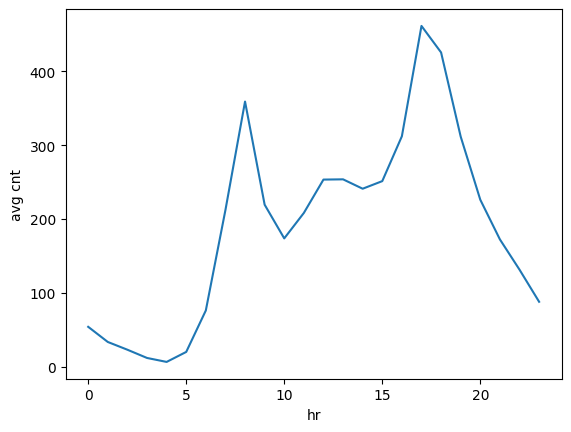

In [149]:
# 1b) OPTIONAL: 1–2 plots total (delete if unused)
avg_by_hr = df.groupby("hr")["cnt"].mean()
plt.figure(); avg_by_hr.plot(); plt.xlabel("hr"); plt.ylabel("avg cnt"); plt.show()


** [Optional section 1(b)] Expected output (example):**
- df shape: (17379, 17)

**Preview (df.head()) should look like:**
| instant | dteday     | season | yr | mnth | hr | holiday | weekday | workingday | weathersit | temp | atemp | hum | windspeed | casual | registered | cnt |
|--------:|------------|-------:|---:|-----:|---:|--------:|--------:|-----------:|-----------:|-----:|------:|----:|----------:|-------:|-----------:|----:|
| 1       | 2011-01-01 | 1      | 0  | 1    | 0  | 0       | 6       | 0          | 1          | ...  | ...   | ... | ...       | ...    | ...        | ... |

*(Exact columns and ordering should match the dataset. `dteday` should be datetime and sorted with `hr`.)*


## 2) Train/Val/Test split + preprocessing (no leakage)  **[Marks: 2.5/15]**
**STOP:** do not proceed to modelling until this section is correct.

**Required split (chronological):** 70% train, 15% val, 15% test.

**Required preprocessing:**
- One-hot encode categorical features.
- Standardise numeric features using **train statistics only**.

**Dummy output example:**
```
Split sizes: 12165 2607 2607
X_train shape: (12165, 61)
X_train | NaN=0 | Inf=0
```


In [ ]:
# 2) Split + preprocessing  [Marks: 3/15]
# STOP: you cannot proceed until this section is correct.

# TODO:
# 1) Define label_col, cat_cols, num_cols (see spec).
label_col = "cnt"
cat_cols = ["season","yr","mnth","hr","holiday","weekday","workingday","weathersit"]
num_cols = ["temp","atemp","hum","windspeed"]
keep_cols = cat_cols + num_cols + [label_col]
# 2) Perform chronological split: first 70% train, next 15% val, last 15% test.
train_size = int(round(0.70 * len(df)))
val_size = int(round(0.15 * len(df)))
test_size = int(round(0.15 * len(df)))

train_df = df.iloc[:train_size].copy()
val_df = df.iloc[train_size:train_size + val_size].copy()
test_df = df.iloc[train_size + val_size:train_size + val_size + test_size].copy()
# 3) One-hot encode cat_cols on train; apply same columns to val/test (reindex).
train_df_cat = pd.get_dummies(train_df[cat_cols], columns=cat_cols)
val_df_cat = pd.get_dummies(val_df[cat_cols], columns=cat_cols).reindex(columns=train_df_cat.columns, fill_value=0)
test_df_cat = pd.get_dummies(test_df[cat_cols], columns=cat_cols).reindex(columns=train_df_cat.columns, fill_value=0)
# 4) Standardise num_cols using TRAIN mean/std only; apply to val/test.
num_means = train_df[num_cols].mean()
num_stds = train_df[num_cols].std()
train_df_num = (train_df[num_cols] - num_means) / num_stds
val_df_num = (val_df[num_cols] - num_means) / num_stds
test_df_num = (test_df[num_cols] - num_means) / num_stds
# 5) Concatenate categorical + numeric features to create X_train/X_val/X_test (float32).
X_train = pd.concat([train_df_cat, train_df_num], axis=1).values.astype(np.float32)
X_val = pd.concat([val_df_cat, val_df_num], axis=1).values.astype(np.float32)
X_test = pd.concat([test_df_cat, test_df_num], axis=1).values.astype(np.float32)
# 6) Create y_train/y_val/y_test from label_col (float32).
y_train = train_df[label_col].values.astype(np.float32)
y_val = val_df[label_col].values.astype(np.float32)
y_test = test_df[label_col].values.astype(np.float32)
# 7) Print split sizes + X_train shape.
print(f"Split sizes: train={len(X_train)}, val={len(X_val)}, test={len(X_test)}")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")
# 8) Print finite checks (NaN/Inf counts) for all X and y arrays.
for name, arr in [("X_train",X_train),("X_val",X_val),("X_test",X_test), ("y_train",y_train),("y_val",y_val),("y_test",y_test)]:
    print(f"{name}, NaN= {np.isnan(arr).sum()}, Inf= {np.isinf(arr).sum()}")

# TODO: implement splitting and preprocessing


Split sizes: train=12165, val=2607, test=2607
X_train shape: (12165, 61), y_train shape: (12165,)
X_val shape: (2607, 61), y_val shape:   (2607,)
X_test shape: (2607, 61), y_test shape:  (2607,)
X_train, NaN= 0, Inf= 0
X_val  , NaN= 0, Inf= 0
X_test , NaN= 0, Inf= 0
y_train, NaN= 0, Inf= 0
y_val  , NaN= 0, Inf= 0
y_test , NaN= 0, Inf= 0


**Expected output (example):**
- Split sizes: train=12165, val=2607, test=2607
- X_train shape: (12165, 61) | y_train shape: (12165,)
- X_val shape:   (2607, 61)  | y_val shape:   (2607,)
- X_test shape:  (2607, 61)  | y_test shape:  (2607,)

**Finite checks (example):**
X_train | NaN=0 | Inf=0
X_val   | NaN=0 | Inf=0
X_test  | NaN=0 | Inf=0
y_train | NaN=0 | Inf=0
y_val   | NaN=0 | Inf=0
y_test  | NaN=0 | Inf=0

*(Exact feature count may differ if you change encoding settings, but train/val/test must align and have no NaNs/Infs.)*


## 3) Metrics  **[Marks: 0.5/15]**
Primary metric: **RMSE(log1p)**. Use consistently for baseline and all experiments.


In [151]:
# 3) Metrics  [Marks: 1/15]
# TODO:
# Implement:
# - rmse(y_true, y_pred)
# - rmse_log1p(y_true, y_pred) where y_pred is clipped at >=0 before log1p
# - evaluate_predictions(y_true, y_pred) returning a dict with keys:
#   rmse_log1p, mae_raw, rmse_raw

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def rmse_log1p(y_true, y_pred):
    y_pred = np.clip(y_pred, a_min=0, a_max=None)
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))

def evaluate_predictions(y_true, y_pred):
    return {
        "rmse_log1p": round(float(rmse_log1p(y_true, y_pred)), 4),
        "mae_raw": round(float(mean_absolute_error(y_true, y_pred)), 4),
        "rmse_raw": round(float(rmse(y_true, y_pred)), 4)
    }


 **Expected output (example):**
A metrics dict should look like:

{
  "rmse_log1p": 0.35,
  "mae_raw": 50.2,
  "rmse_raw": 80.7
}

*(Values will differ. The key is: returns a dict with exactly these keys and numeric values.)*


## 4) Baseline model (required)  **[Marks: 0.5/15]**
**STOP:** baseline required before deep learning.


In [152]:
# 4) Baseline (Ridge)  [Marks: 1/15]
# STOP: do not proceed until you have a baseline.

# TODO:
# 1) Fit a Ridge regression baseline on (X_train, y_train).
from sklearn.linear_model import Ridge
baseline = Ridge()
baseline.fit(X_train, y_train)
# 2) Predict on X_val.
baseline_val_pred = baseline.predict(X_val)
# 3) Compute metrics using evaluate_predictions(y_val, baseline_val_pred).
baseline_metrics = evaluate_predictions(y_val, baseline_val_pred)
# 4) Print "Baseline VAL: ..." with the metrics dict.
print(f"Baseline VAL: {baseline_metrics}")

# TODO: implement baseline


Baseline VAL: {'rmse_log1p': 1.0436, 'mae_raw': 110.6162, 'rmse_raw': 141.6182}


**Expected output (example):**
Baseline VAL: {'rmse_log1p': 0.44, 'mae_raw': 70.1, 'rmse_raw': 105.8}

*(Values will differ. The key is: baseline runs, prints a dict with the three metrics on VAL.)*


## 5) Implement the deep MLP (>=3 hidden layers)  **[Marks: 2/15]**
**STOP:** Sections 6–9 depend on this.

You must implement `MLPRegressor` with >=3 hidden layers and activations.


In [153]:
# 5) Deep MLP model (TODO)  [Marks: 2/15]
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class MLPRegressor(nn.Module):
    def __init__(self, in_dim, hidden=(256,128,64), activation="relu", dropout=0.0):
        super().__init__()
        layers = []
        
        if activation == "relu":
            act_fn = nn.ReLU
        else:
            act_fn = nn.Identity

        prev_dim = in_dim
        # TODO: build layers (len(hidden) must be >= 3)
        for h in hidden:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(act_fn())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))
        self.network = nn.Sequential(*layers)


    def forward(self, x):
        # TODO
        return self.network(x).reshape(-1)

# After implementing:
model = MLPRegressor(in_dim=X_train.shape[1], hidden=(256,128,64))
print(model)
print("Total parameters:", sum(p.numel() for p in model.parameters()))


Device: cpu
MLPRegressor(
  (network): Sequential(
    (0): Linear(in_features=61, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)
Total parameters: 57089


**Expected output (example):**
- Printed model summary (any readable representation is fine)
- Total parameters: 4xxxx

**Minimum requirement reminders:**
- Must be a **deep** MLP (≥ 3 hidden layers)
- Output shape must match target shape (one prediction per row)

*(Exact parameter count differs depending on your layer sizes.)*


## 6) Implement training loop (backprop + optimiser)  **[Marks: 2/15]**
**STOP:** Sections 7–9 depend on this.

Must support: Adam + Momentum-SGD, MSE + MAE, validation each epoch, early stopping, stability (e.g., grad clipping).


In [ ]:
# 6) Training utilities + train_model (TODO)  [Marks: 3/15]
from torch.utils.data import TensorDataset, DataLoader

@torch.no_grad()
def predict(model, X, batch_size=1024):
    """
    Required: batched prediction that works when the final batch is smaller.
    DO NOT use np.vstack on 1D arrays (it will fail on the last batch).
    """
    model.eval()
    preds = []
    for i in range(0, len(X), batch_size):
        xb = torch.from_numpy(X[i:i+batch_size]).to(device)
        yb = model(xb).detach().cpu().numpy()
        preds.append(yb.reshape(-1))  # force 1D
    return np.concatenate(preds, axis=0)


def train_model(cfg, X_tr, y_tr, X_va, y_va):
    # TODO: implement training loop + early stopping + stability guards
    
    model = MLPRegressor(in_dim=X_tr.shape[1], hidden=cfg["hidden"], activation=cfg["activation"], dropout=cfg["dropout"]).to(device)
    
    if cfg["optimizer"] == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=1e-5)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=cfg["lr"], momentum=0.9, weight_decay=1e-5)

    if cfg["loss"] == "mse":
        loss_fn = nn.MSELoss()
    else:
        loss_fn = nn.L1Loss()

    X_train = torch.from_numpy(X_tr)
    y_train = torch.from_numpy(y_tr)
    dataset = TensorDataset(X_train, y_train)
    dataloader = DataLoader(dataset, batch_size=cfg["batch_size"], shuffle=True)

    best_val_loss = float("inf")
    best_weights = None
    patience_counter = 0

    epoch_history = []

    for epoch in range(cfg["max_epochs"]):

        model.train()

        for xb, yb in dataloader:

            xb, yb = xb.to(device), yb.to(device)
            
            optimizer.zero_grad()

            preds = model(xb)
            
            loss = loss_fn(preds, yb)
            loss.backward()

            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

        
        train_preds = predict(model, X_tr)
        train_metrics = evaluate_predictions(y_tr, train_preds)

        val_preds = predict(model, X_va)
        val_metrics = evaluate_predictions(y_va, val_preds)
        val_rmse_log1p = val_metrics["rmse_log1p"]

        epoch_history.append({"epoch": epoch+1, 
                              "train_rmse_log1p": train_metrics["rmse_log1p"], 
                              "train_mae_raw": train_metrics["mae_raw"], 
                              "train_rmse_raw": train_metrics["rmse_raw"], 
                              "val_rmse_log1p": val_metrics["rmse_log1p"], 
                              "val_mae_raw": val_metrics["mae_raw"], 
                              "val_rmse_raw": val_metrics["rmse_raw"]})

        if val_rmse_log1p < best_val_loss:
            best_val_loss = val_rmse_log1p
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if cfg.get("early_stopping", False) and cfg.get("patience", 0) > 0:
            if patience_counter >= cfg["patience"]:
                print(f"Early stop reached at epoch: {epoch+1} | best_val_rmse_log1p: {best_val_loss:.4f}")
                break
        
        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1} val_rmse_log1p: {val_metrics['rmse_log1p']:.4f}")

    model.load_state_dict(best_weights)
    
    history_df = pd.DataFrame(epoch_history)
    return model, history_df

    

**Expected output (example):**
During training, you should see periodic progress logs such as:

epoch 20 val rmse_log1p 0.41
epoch 40 val rmse_log1p 0.36
Early stop @ epoch 63 | best rmse_log1p 0.33

*(Exact wording can differ, but you must show training progress and validation metric over epochs.)*


## 7) Sanity check: tiny overfit test (required)  **[Marks: 0.5/15]**
Train on 256 samples and show training error drops substantially.


In [155]:
# 7) Tiny overfit test (TODO)  [Marks: 1/15]
# STOP: requires Sections 5 and 6 implemented.
# TODO: use first 256 training samples, disable early stopping, confirm training error drops.
sanity_check_cfg = {
    "hidden": (256, 128, 64),
    "activation": "relu",
    "dropout": 0.0,
    "optimizer": "adam",
    "loss": "mse",
    "lr" : 1e-3,
    "batch_size": 64,
    "max_epochs": 200,
    "early_stopping": False,
    "patience": 0
}

overfit_model, overfit_history_df = train_model(sanity_check_cfg, X_train[:256], y_train[:256], X_val, y_val)

overfit_history_df[["epoch", "train_rmse_log1p", "train_mae_raw", "train_rmse_raw"]].iloc[19::20]

Epoch 20 val_rmse_log1p: 2.0382
Epoch 40 val_rmse_log1p: 1.2307
Epoch 60 val_rmse_log1p: 1.1848
Epoch 80 val_rmse_log1p: 1.1929
Epoch 100 val_rmse_log1p: 1.2241
Epoch 120 val_rmse_log1p: 1.2216
Epoch 140 val_rmse_log1p: 1.1813
Epoch 160 val_rmse_log1p: 1.1456
Epoch 180 val_rmse_log1p: 1.1340
Epoch 200 val_rmse_log1p: 1.1333


,epoch,train_rmse_log1p,train_mae_raw,train_rmse_raw
19,20,1.2924,32.8821,42.6501
39,40,0.7634,17.3203,23.5312
59,60,0.3807,6.8548,9.4512
79,80,0.2489,4.6069,6.4148
99,100,0.2188,3.3920,4.9166
119,120,0.1938,2.3979,3.5838
139,140,0.1450,2.0142,2.9828
159,160,0.1024,1.1157,1.9245
179,180,0.0907,0.8439,1.5910
199,200,0.0789,0.8270,1.3953


**Expected output (example):**
Tiny overfit metrics (train on small subset): 
{'rmse_log1p': 0.05, 'mae_raw': 5.2, 'rmse_raw': 8.1}

And a small tail of the training history table like:

| epoch | rmse_log1p | mae_raw | rmse_raw |
|------:|-----------:|--------:|---------:|
| 180   | 0.06       | 6.0     | 9.0      |
| 200   | 0.05       | 5.2     | 8.1      |

*(Your overfit result doesn’t need to be exactly this low, but it should clearly improve a lot—otherwise something is wrong.)*


## 8) Controlled experiments (minimum 4 runs) + results table  **[Marks: 3/15]**
**STOP:** requires Sections 5–6.

Minimum grid requirements:
- Optimisers: Adam AND Momentum-SGD
- Losses: MSE AND MAE
- Learning rates: >=2 distinct values across runs
- Regularisation: >=1 method (early stopping is acceptable)

You must produce `results_df` and store `histories` for learning curves.


In [156]:
# 8) Experiments (TODO)  [Marks: 2/15]
# STOP: You should only start this section after Sections 5–7 work.

# OUTPUT REQUIRED IN THIS SECTION:
# 1) A Python list named `configs` with >= 4 experiment dictionaries.

configs = []

optimizers = ["adam", "sgd"]
losses = ["mse", "mae"]
lrs = [1e-3,3e-4]

for optimizer in optimizers:
    for loss in losses:
            for lr in lrs:
                    config = {
                        "hidden": (256, 128, 64), 
                        "activation": "relu",
                        "dropout": 0.1,
                        "optimizer": optimizer,
                        "loss": loss,
                        "lr": lr,
                        "batch_size": 64,
                        "max_epochs": 200,
                        "early_stopping": True,
                        "patience": 10,
                        }
                    configs.append(config)


# 2) A loop that runs each config and creates:
#    - `models`     : dict mapping run_name -> trained model
#    - `histories`  : dict mapping run_name -> per-epoch history DataFrame (must include columns: epoch, rmse_log1p)
#    - `results_df` : DataFrame comparing validation metrics across runs, sorted by rmse_log1p ascending

models = {}
histories = {}
results = []

for i, cfg in enumerate(configs):

    run_name = f"{cfg['optimizer']}_{cfg['loss']}_lr{cfg['lr']}"

    model, history_df = train_model(cfg, X_train, y_train, X_val, y_val)

    models[run_name] = model
    histories[run_name] = history_df[["epoch", "val_rmse_log1p", "val_mae_raw", "val_rmse_raw"]]
  
    best_metrics = history_df.sort_values("val_rmse_log1p").iloc[0].to_dict()

    results.append({
        "run": run_name,
        "optim": cfg["optimizer"],
        "loss": cfg["loss"],
        "lr": cfg["lr"],
        "regularisation": "early_stopping, dropout, L2",
        "val_rmse_log1p": best_metrics["val_rmse_log1p"],
        "val_mae_raw": best_metrics["val_mae_raw"],
        "val_rmse_raw": best_metrics["val_rmse_raw"]
    })

# 3) Display `results_df`.

results_df = pd.DataFrame(results).sort_values("val_rmse_log1p").reset_index(drop=True)

results_df

# CONTROLLED EXPERIMENTS REQUIREMENT (minimum 4 runs):
# - Hold constant across runs: data split, preprocessing, architecture (hidden dims), batch_size, epochs,
#   early_stopping settings (early_stopping=True, patience fixed), and metric (RMSE(log1p)).
# - Vary across runs: optimiser (Adam vs Momentum-SGD) AND loss (MSE vs MAE).
# - Use stable LRs (e.g., Adam ~1e-3; Momentum may need smaller, e.g., 3e-4) and include gradient clipping.
#
# NOTE: You MUST use validation metrics (not test) to compare runs and select the best run.


Epoch 20 val_rmse_log1p: 0.4599
Early stop reached at epoch: 22 | best_val_rmse_log1p: 0.4159
Epoch 20 val_rmse_log1p: 0.3869
Epoch 40 val_rmse_log1p: 0.3364
Early stop reached at epoch: 46 | best_val_rmse_log1p: 0.3236
Early stop reached at epoch: 17 | best_val_rmse_log1p: 0.3049
Epoch 20 val_rmse_log1p: 0.3688
Epoch 40 val_rmse_log1p: 0.3174
Epoch 60 val_rmse_log1p: 0.3335
Early stop reached at epoch: 61 | best_val_rmse_log1p: 0.3030
Epoch 20 val_rmse_log1p: 1.0429
Epoch 40 val_rmse_log1p: 0.7892
Epoch 60 val_rmse_log1p: 0.5716
Epoch 80 val_rmse_log1p: 0.4914
Epoch 100 val_rmse_log1p: 0.4411
Epoch 120 val_rmse_log1p: 0.4199
Early stop reached at epoch: 132 | best_val_rmse_log1p: 0.3973
Early stop reached at epoch: 20 | best_val_rmse_log1p: 1.2631
Epoch 20 val_rmse_log1p: 0.8571
Epoch 40 val_rmse_log1p: 0.6356
Epoch 60 val_rmse_log1p: 0.4829
Epoch 80 val_rmse_log1p: 0.3851
Epoch 100 val_rmse_log1p: 0.3754
Early stop reached at epoch: 118 | best_val_rmse_log1p: 0.3296
Epoch 20 val_rmse

,run,optim,loss,lr,regularisation,val_rmse_log1p,val_mae_raw,val_rmse_raw
0,adam_mae_lr0.0003,adam,mae,0.0003,"early_stopping, dropout, L2",0.3030,40.1989,61.7456
1,adam_mae_lr0.001,adam,mae,0.0010,"early_stopping, dropout, L2",0.3049,43.8135,67.9073
2,adam_mse_lr0.0003,adam,mse,0.0003,"early_stopping, dropout, L2",0.3236,40.5506,62.6791
3,sgd_mae_lr0.001,sgd,mae,0.0010,"early_stopping, dropout, L2",0.3296,45.7066,68.7670
4,sgd_mse_lr0.001,sgd,mse,0.0010,"early_stopping, dropout, L2",0.3973,42.5695,64.1916
5,adam_mse_lr0.001,adam,mse,0.0010,"early_stopping, dropout, L2",0.4159,44.3975,66.2954
6,sgd_mae_lr0.0003,sgd,mae,0.0003,"early_stopping, dropout, L2",0.4540,60.0582,83.9995
7,sgd_mse_lr0.0003,sgd,mse,0.0003,"early_stopping, dropout, L2",1.2631,185.3021,248.4569


**Dummy example of the required `results_df` output format (your numbers will differ):**

| run             | optim    | loss | lr     | regularisation | rmse_log1p | mae_raw | rmse_raw |
| --------------- | -------- | ---- | ------ | -------------- | ---------- | ------- | -------- |
| adam_mae_lr1e-3 | adam     | mae  | 0.0010 | early_stopping | 0.3184     | 46.2    | 74.9     |
| adam_mse_lr1e-3 | adam     | mse  | 0.0010 | early_stopping | 0.3327     | 48.0    | 77.8     |
| mom_mae_lr3e-4  | momentum | mae  | 0.0003 | early_stopping | 0.3519     | 52.3    | 83.6     |
| mom_mse_lr3e-4  | momentum | mse  | 0.0003 | early_stopping | 0.3688     | 54.1    | 86.9     |


### 8b) Experimental design notes (markdown)  **[Marks: 1/15]**
Write 150–250 words explaining what you held constant vs varied, and why RMSE(log1p) is used.


**Expected format (example):**
A single paragraph of 150–250 words that explicitly states:
- what you held constant,
- what you varied (optimiser + loss),
- why RMSE(log1p) is used for counts.

*(Your wording will differ. Keep it concise and specific to your runs.)*

My experiments evaluated three variables: the optimiser, the loss function, and the learning rate. Across these three factors, 8 configurations were generated. The network was trained with Adam, SGD, MSE, and MAE, using learning rates of 1e-3 and 3e-4. MSE and MAE were both included as they differ in sensitivity to outliers, which is important given the skew in the target distribution. Adam and SGD were selected because they represent adaptive and fixed learning-rate optimisation strategies, making their comparison particularly informative.

Regularisation techniques were held constant throughout the experiment, with early stopping at a patience of 10, dropout at 0.1, and L2 weight decay at 1e-5. Stability and training parameters remained fixed: a network architecture of shape (256-128-64), a batch size of 64, a maximum of 200 epochs, a gradient clipping norm of 1, and SGD momentum of 0.9. The purpose of holding these constants is to isolate the effects of the varied factors, ensuring that any differences in validation performance can be attributed directly to the variables at hand. These values were chosen through informal exploratory runs before the formal experiments, and produced stable training behaviour throughout.

The distribution of the bike-count dataset drives the choice of RMSE(log1p). As seen in Q1's EDA plot, the bike counts are right-skewed, with a peak occurring around 17:00. This means that a raw RMSE score would be heavily influenced by these high-demand hours. The use of log1p compresses the scale, making errors comparable across low and high-demand periods.

## 9) Plot learning curves + choose final model  **[Marks: 2/15]**

You must produce the following outputs in cells 9a and 9b.

**9a (plot cell):**
1) Identify the **best 2 runs** using **validation RMSE(log1p)** from `results_df` (lowest is best).
2) Plot **validation RMSE(log1p) vs epoch** for those 2 runs on the **same figure**.
3) The plot must include:
- x-axis label: `epoch`
- y-axis label: `val RMSE(log1p)`
- legend with the **run names**

**9b (selection + test once):**
1) Select the **single best run** using **validation RMSE(log1p) only** (lowest wins).
2) Print one line exactly in this format:  
`Final selected run (by validation only): <run_name> | VAL rmse_log1p=<value>`
3) Evaluate the selected model on the **test set exactly once** and print the test metrics dict.
4) Print one final line:  
`Test evaluated ONCE after selection.`
5) Do **NOT** compute test metrics for multiple runs.


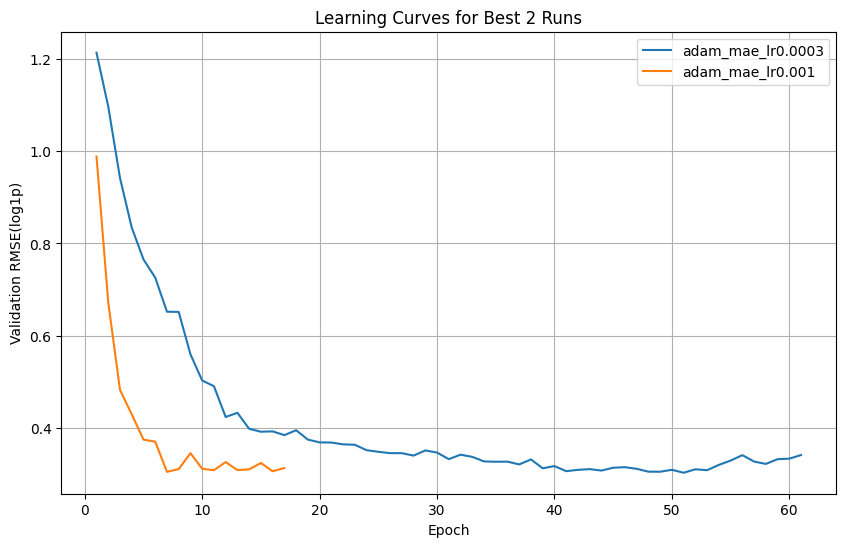

In [157]:


# 9a) Plot learning curves (required output)
#  TODO
# Output required in this cell:
# 1) Compute best 2 runs based on validation RMSE(log1p) from results_df (lowest is best).
best_2_runs = results_df.nsmallest(2, "val_rmse_log1p")["run"].values
# 2) Plot val RMSE(log1p) vs epoch for those 2 runs on the same figure.
plt.figure(figsize=(10, 6))
for run in best_2_runs:
    history = histories[run]
    plt.plot(history["epoch"], history["val_rmse_log1p"], label=run)
# 3) Must include: x-axis 'epoch', y-axis 'val RMSE(log1p)', legend with run names.
plt.xlabel("Epoch")
plt.ylabel("Validation RMSE(log1p)")
plt.title("Learning Curves for Best 2 Runs")
plt.legend()
plt.grid()
plt.show()

 **Expected output (example):**
A single plot figure showing **two curves**:
- x-axis: epoch
- y-axis: val RMSE(log1p)
- legend: two run names (e.g., `adam_mae_lr1e-3`, `adam_mse_lr1e-3`)

*(No table required here—just the plot with correct labels and legend.)*


In [158]:
# 9b) Final selection + test report (TODO)  [Marks: 1/15]
# TODO: compute test metrics once for your chosen model
best_run = results_df.iloc[0]["run"]
best_val_metrics = results_df.iloc[0][["val_rmse_log1p", "val_mae_raw", "val_rmse_raw"]].to_dict()
best_val_rmse_log1p = best_val_metrics["val_rmse_log1p"]
best_model = models[best_run]

print(f"Final selected run (by validation only): {best_run} | VAL rmse_log1p={best_val_rmse_log1p:.6f}")

test_pred = predict(best_model, X_test)
best_test_metrics = evaluate_predictions(y_test, test_pred)
print("TEST metrics:", best_test_metrics)

print("Test evaluated ONCE after selection.")


Final selected run (by validation only): adam_mae_lr0.0003 | VAL rmse_log1p=0.303000
TEST metrics: {'rmse_log1p': 0.5285, 'mae_raw': 54.6166, 'rmse_raw': 77.1037}
Test evaluated ONCE after selection.


 **Expected output (example):**
Final selected run (by validation only): adam_mae_lr2e-4 | VAL rmse_log1p=0.318400
TEST metrics: {'rmse_log1p': 0.3351, 'mae_raw': 48.7, 'rmse_raw': 78.4}
Test evaluated ONCE after selection.

*(Values will differ. The key is: one selected run, one test evaluation, correct printed lines.)*


## 10) Error analysis (top 10 errors)  **[Marks: 1/15]**
Create a table of the top-10 absolute errors on the test set and add 2–4 bullet explanations.


In [159]:
# 10) Error analysis template (TODO)  [Marks: 1/15]
# Output required in this cell:
# 1) Compute absolute errors on the TEST set: abs(y_test - pred_test_clipped)
test_pred = predict(best_model, X_test)
test_pred_clipped = np.clip(test_pred, a_min=0, a_max=None)
abs_errors = np.abs(y_test - test_pred_clipped)
# 2) Find the top 10 largest absolute errors.
top_10_indices = np.argsort(abs_errors)[-10:]  
top_10_rows = test_df.iloc[top_10_indices].copy()
# 3) Create a DataFrame named analysis_df with exactly these columns:
#    ["dteday","hr","weathersit","temp","hum","windspeed","cnt","pred_cnt","abs_error"]
top_10_rows["pred_cnt"] = test_pred_clipped[top_10_indices]
top_10_rows["abs_error"] = abs_errors[top_10_indices]
analysis_df = top_10_rows[["dteday", "hr", "weathersit", "temp", "hum", "windspeed", "cnt", "pred_cnt", "abs_error"]]
# 4) Display analysis_df (top 10 errors, sorted descending by abs_error).
#
analysis_df = analysis_df.sort_values(by="abs_error", ascending=False)
analysis_df
# NOTE: pred_cnt must be clipped to >= 0 for counts.



,dteday,hr,weathersit,temp,hum,windspeed,cnt,pred_cnt,abs_error
16454,2012-11-23,8,1,0.24,0.87,0.0896,94,639.186951,545.186951
15661,2012-10-19,18,1,0.56,0.83,0.1045,233,718.314026,485.314026
16464,2012-11-23,18,2,0.46,0.44,0.0000,208,653.699341,445.699341
17196,2012-12-24,8,1,0.22,0.69,0.0000,66,507.542725,441.542725
15890,2012-10-30,19,2,0.50,0.68,0.1940,115,555.940308,440.940308
14917,2012-09-18,18,2,0.60,0.88,0.1642,281,706.496704,425.496704
16463,2012-11-23,17,2,0.48,0.39,0.0896,300,714.865479,414.865479
16416,2012-11-21,18,1,0.42,0.38,0.1045,311,710.689148,399.689148
16415,2012-11-21,17,1,0.40,0.40,0.1642,374,731.575867,357.575867
16453,2012-11-23,7,1,0.24,0.81,0.0000,77,429.360901,352.360901


**Expected output (example):**
A displayed `analysis_df` table of the **top 10 largest absolute errors**, with columns:

[dteday, hr, weathersit, temp, hum, windspeed, cnt, pred_cnt, abs_error]

Example format:

| dteday     | hr | weathersit | temp | hum | windspeed | cnt | pred_cnt | abs_error |
|------------|---:|-----------:|-----:|----:|----------:|----:|---------:|----------:|
| 2012-07-xx | 17 | 2          | ...  | ... | ...       | 9xx | 6xx      | 3xx       |
| ...        | .. | ..         | ...  | ... | ...       | ... | ...      | ...       |

*(Exact rows/values differ. The key is correct columns + 10 rows sorted by abs_error.)*


### 10b) Error analysis commentary (markdown)
TODO: add 2–4 bullets interpreting the top errors.


**Expected format (example):**
2–4 bullet points interpreting patterns in the top-error rows. For example:
- Peaks (commute hours) are often underpredicted.
- Certain weather categories show larger errors.
- Holiday/weekend patterns differ from weekdays.
- Some errors likely reflect unobserved factors (events, disruptions).

*(Your bullets must refer to what you see in your table.)*

- All 10 of the biggest errors occur either at 8am or around 6pm, which are standard times for commuters heading to and from work. These periods cause high levels of demand, as evident from the graph in Q1, and the model has clearly learned to predict this output during these times. However, these specific days record unusually low demand, resulting in larger over-predictions by the model. This suggests the model over-relies on the commuter hour as a demand signal, treating it as a reliable positive indicator regardless of what other features suggest. 

- Alongside Christmas Eve (2012-12-24), we see repeated entries from 2012-11-21 and 2012-11-23, both exhibiting notably low counts. The 22nd of November 2012 was the American holiday of Thanksgiving, with the 23rd forming part of the public holiday weekend. This directly explains the unusually low demand levels across these dates. Similarly, 2012-10-30 falls on the day after Hurricane Sandy made contact with the east coast of the USA, a likely cause of the severely low count of 115. These residuals are largely unavoidable; the model had no way of knowing these days would see reduced demand, as neither the holiday context nor the external disruption is represented anywhere in the feature set.

- All 10 of the greatest errors occur on days with weathersit values of 1 or 2, alongside typical humidity and temperature values with low windspeed - conditions that collectively suggest favourable cycling weather. Despite this, actual counts remain well below predictions. This indicates that the model over-relies on favourable weather as a positive demand signal, when in fact other, more influential factors are at play. This mirrors the earlier observation that the model places too much emphasis on the hour feature, suggesting it struggles to capture interactions between variables and instead treats them too independently.

- Across the top 10, the errors are not evenly distributed - the largest single error (545) is over 50% larger than the smallest (352), suggesting the model struggles most severely on specific combinations of feature values, rather than performing uniformly poorly across the dataset. These outliers all share a common combination: a peak commute hour, favourable weather conditions, and an unobserved factor causing a decrease in demand, such as a public holiday or an external disruption event. However, 2012-10-19 and 2012-09-18 seem to be exceptions to this, suggesting that some residuals remain unaccounted for by the dataset's features, and that additional external data sources, such as societal event listings and public transport disruptions would be needed to explain them fully.

## 11) Reflection & limitations  **[Marks: 1/15]**
Write 400–600 words referencing your experiments.


**Expected format (example):**
400–600 words that:
- references your experiment runs (Section 8 results),
- explains what worked/didn’t and why,
- discusses limitations (data/features/model),
- proposes plausible next steps (without adding new experiments).

*(No code output required—this is assessed from your writing + references to your results.)*

Looking at the results, the best performing run was adam_mae_lr0.0003 with an rmse_log1p of 0.303, closely followed by adam_mae_lr0.001 at 
0.3049. In fact, the top 3 runs all used Adam, while the two worst-performing runs used SGD. The best performing model achieved a test rmse_log1p of 0.5285, a notable rise from its validation score of 0.303, showing some sign of overfitting. Although, this gap is partly explained by the non-stationary nature of the dataset and the fact that the test set covers the period where this effect is most pronounced.

As mentioned, Adam consistently outperformed SGD at every learning rate and loss combination. This is expected given Adam's adaptive per-parameter learning rates, making it less sensitive to the mix of categorical and continuous features in this dataset. At a lr of 3e-4, SGD performance degraded severely, with the MSE variant producing a val score of 1.2631, even worse than that of the Ridge baseline's 1.0436. Without adaptive rescaling, SGD requires a well-chosen learning rate to converge within a fixed number of epochs.

MAE loss outperformed MSE under Adam and SGD across both learning rates. MSE's squared penalty amplifies residual errors during peak commuter hours, causing the model to over-prioritise these demand spikes during training. MAE's linear penalty distributes the model's learning more evenly across the bike demand range, proving to be a better match alongside the rmse(log1p) metric, which similarly diminishes the magnitude of large residual errors.

The learning curves for the two best runs show clear differences in convergence behaviour. The lr=1e-3 run converges quickly, reaching early stopping at epoch 17, while lr=3e-4  descends more gradually to epoch 61. Although both runs appear to approach the same minimum loss, the lr=3e-4 does reach a lower final value. In light of this, lr=3e-4 is the more practical choice. It is worth noting that the blue curve had plateaued by epoch 40, meaning a smaller patience value would have stopped this run earlier with minimal effect on final performance.

Two dataset limitations constrain the overall performance of our experiments. Firstly, the dataset exhibits non-stationary behaviour — mean hourly demand grew from 144 in 2011 to 235 in 2012. However, with only around a year and a half of training data, the model struggles to capture this longer-term upward trend. Secondly, several of the categorical dataset features provide only binary signals to the model: the 'holiday' indicator cannot distinguish between holiday types or their effect on demand, and the ordinal 'weathersit' variable reduces weather to just four broad categories.

A major limitation of the MLP model is that it treats every row as an independent sample with no memory of prior entries, a serious flaw given the time-series nature of this dataset. It is likely the previous hour's count is highly predictive of the next, and the current MLP cannot exploit this relationship. This represents a misalignment between the dataset and model choice that no regularisation techniques or hyperparameter tuning could resolve.

There are three next steps for this experiment. Adding lag features (t-1 and t-24) to the existing dataset would directly address the time-series problem. Additionally, training separate models for 'casual' and 'registered' users before summing predictions could better capture their fundamentally different demand patterns. Finally, replacing the binary 'holiday' indicator with a categorical encoding of the holiday type and a numerical holiday-window interval value would give the model better context around public holidays.

## 12) Required JSON summary  [Marks: 0/15], the summary will be used to corroborate your results and update the marks on Moodle. 
Generate `submission_summary.json` (marker will check it).


In [160]:
# 12) submission_summary.json (TODO)  [Marks: 1/15]
import json, platform, torch


# Derive best validation metrics from results_df (already computed on val)
best_row = results_df.loc[results_df["run"] == best_run].iloc[0]

best_val_metrics = {
    "rmse_log1p": float(best_row["val_rmse_log1p"]),
    "mae_raw": float(best_row["val_mae_raw"]),
    "rmse_raw": float(best_row["val_rmse_raw"]),
}


submission_summary = {
  "student_id": "wtb24",
  "python_version": platform.python_version(),
  "torch_version": torch.__version__,
  "split_sizes": {"train": int(len(train_df)), "val": int(len(val_df)), "test": int(len(test_df))},
  "baseline_metrics_val": {**baseline_metrics},
  "tiny_overfit_metrics_train": {**overfit_history_df[["train_rmse_log1p", "train_mae_raw", "train_rmse_raw"]].iloc[[179, 199]].to_dict(orient="index")},
  "best_run_name": best_run,
  "best_val_metrics": best_val_metrics,
  "best_test_metrics": best_test_metrics,
  "experiments": [results_df.to_dict(orient="records")]
}
with open("submission_summary.json","w") as f:
    json.dump(submission_summary, f, indent=2)
print("Wrote submission_summary.json")


Wrote submission_summary.json


**Expected output (example):**
Wrote submission_summary.json

And the JSON file should contain keys similar to:

{
  "student_id": "YOUR_USER_ID",
  "python_version": "3.11.x",
  "torch_version": "2.x.x",
  "split_sizes": {"train": 12165, "val": 2607, "test": 2607},
  "baseline_metrics_val": {"rmse_log1p": 0.xx, "mae_raw": xx.x, "rmse_raw": xx.x},
  "tiny_overfit_metrics_train": {"rmse_log1p": 0.xx, "mae_raw": xx.x, "rmse_raw": xx.x},
  "best_run_name": "adam_mae_lr1e-3",
  "best_val_metrics": {...},
  "best_test_metrics": {...},
  "experiments": [ ... list of dicts ... ]
}

*(Exact numbers differ. The key is: file is written and contains the required fields.)*
